# Smart Greenhouse Monitoring System

This `.ipynb` file is responsible for the machine learning framework of the Smart Greenhouse Monitoring System.

## Data Preprocessing

For data preprocessing, we first need to load our dataset.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("greenhouse_crop_yields.csv")

We need to drop rows where our target attribute `yield_kg_per_m2` is missing.

In [7]:
df = df.dropna(subset=['yield_kg_per_m2']).copy()

Since `day_to_maturity` already captures the growth duration, we extract the planting month and drop the raw string dates.

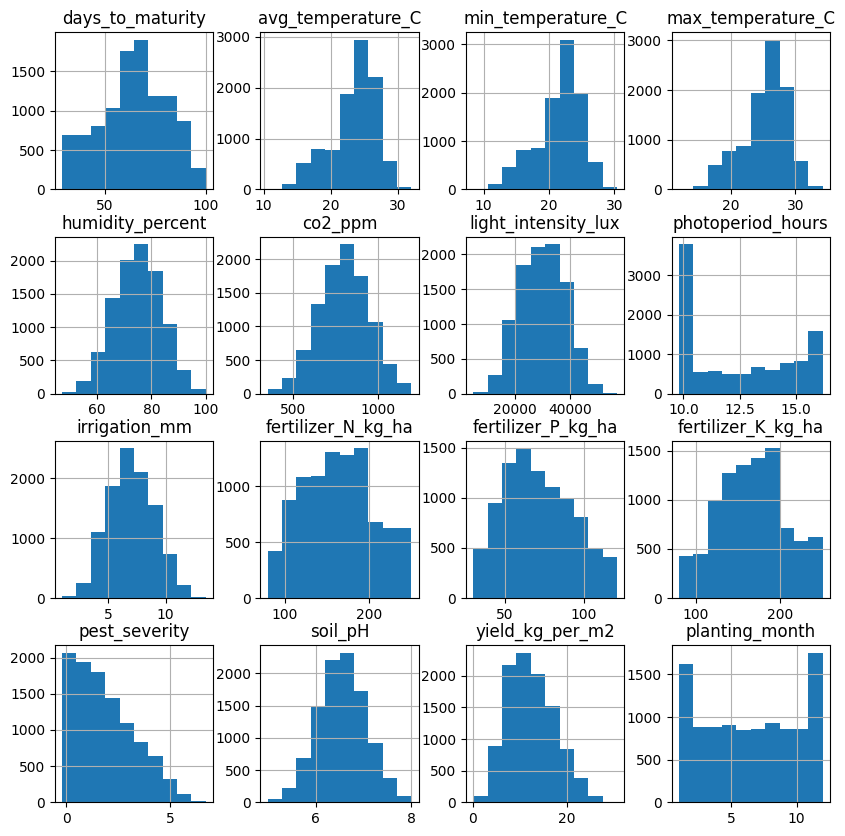

In [8]:
df['planting_date'] = pd.to_datetime(df['planting_date'])
df['planting_month'] = df['planting_date'].dt.month
df = df.drop(columns=['planting_date', 'harvest_date', 'greenhouse_id'])

df.hist(figsize=(10,10))
plt.show()

We then handle missing numerical values using the median of that specific crop.

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('yield_kg_per_m2')
categorical_cols = ['crop_type', 'variety']

for col in numeric_cols:
    df[col] = df.groupby('crop_type')[col].transform(lambda x: x.fillna(x.median()))

We handle missing categorical values using the mode of that specific crop.

In [10]:
for col in categorical_cols:
    df[col] = df.groupby('crop_type')[col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
    )

We clip outliers within each crop's distribution.

In [11]:
def clip_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series.clip(lower=lower_bound, upper=upper_bound)

for col in numeric_cols:
    df[col] = df.groupby('crop_type')[col].transform(clip_outliers)

We convert `crop_type` and `variety` into numeric attribute via One-Hot Encoding.

In [12]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

We scale the numerical attributes so that the larger values do not dominate the ML algorithms.

In [13]:
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [14]:
print("Preprocessing complete. Data shape:", df.shape)
display(df.head())

Preprocessing complete. Data shape: (10400, 32)


,days_to_maturity,avg_temperature_C,min_temperature_C,max_temperature_C,humidity_percent,co2_ppm,light_intensity_lux,photoperiod_hours,irrigation_mm,fertilizer_N_kg_ha,...,variety_English,variety_Habanero,variety_Heirloom,variety_Iceberg,variety_Jalapeno,variety_Leaf,variety_Pickling,variety_Roma,variety_Romaine,variety_Slicing
0,0.151338,1.242991,1.245606,1.551161,-0.164732,0.811919,-1.680928,-1.064403,1.411161,0.083262,...,False,False,False,False,False,False,False,False,False,False
1,-0.092689,0.289624,-0.156196,0.583514,0.692604,-0.125207,-0.325796,-1.064403,1.108442,0.253695,...,True,False,False,False,False,False,False,False,False,False
2,0.700398,0.140660,-0.273013,0.202320,0.192491,0.145518,0.059696,-1.064403,-0.001531,1.714549,...,False,False,False,False,False,False,False,False,False,False
3,1.188452,0.974856,1.157994,1.257935,0.132954,-0.625008,1.720120,1.144505,-0.808783,0.083262,...,False,False,True,False,False,False,False,False,False,False
4,0.151338,0.200246,0.252663,0.348933,-0.617215,0.839686,-0.986712,-1.064403,0.704815,-1.499331,...,False,False,False,False,False,False,False,False,False,True


We then split the dataset into `test` and `train` for regression models.

In [15]:
# Separate the features (X) from the target (y)
X = df.drop(columns=['yield_kg_per_m2'])
y = df['yield_kg_per_m2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Total dataset size:", df.shape)
print("X_train size (80% features):", X_train.shape)
print("X_test size (20% features):", X_test.shape)
print("y_train size (80% target):", y_train.shape)
print("y_test size (20% target):", y_test.shape)

Total dataset size: (10400, 32)
X_train size (80% features): (8320, 31)
X_test size (20% features): (2080, 31)
y_train size (80% target): (8320,)
y_test size (20% target): (2080,)


## Machine Learning Models

We will run various ML models for our dataset.

### K-Nearest Neighbor

For KNN, we will check the 5 nearest neighbors ($k=5$).

In [16]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_y_pred = knn_model.predict(X_test)

knn_mae = mean_absolute_error(y_test, knn_y_pred)
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_y_pred))
knn_r2 = r2_score(y_test, knn_y_pred)

print(f"MAE: {knn_mae:.4f} kg/m²")
print(f"RMSE: {knn_rmse:.4f} kg/m²")
print(f"R-squared: {knn_r2:.4f}")

MAE: 2.0060 kg/m²
RMSE: 2.5158 kg/m²
R-squared: 0.7350


### Decision Tree

In [17]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_y_pred = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_y_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_y_pred))
dt_r2 = r2_score(y_test, dt_y_pred)

print(f"MAE: {dt_mae:.4f} kg/m²")
print(f"RMSE: {dt_rmse:.4f} kg/m²")
print(f"R-squared: {dt_r2:.4f}")

MAE: 2.3188 kg/m²
RMSE: 2.9773 kg/m²
R-squared: 0.6289


### Random Forest

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_y_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_y_pred))
rf_r2 = r2_score(y_test, rf_y_pred)

print(f"MAE: {rf_mae:.4f} kg/m²")
print(f"RMSE: {rf_rmse:.4f} kg/m²")
print(f"R-squared: {rf_r2:.4f}")

MAE: 1.6531 kg/m²
RMSE: 2.0811 kg/m²
R-squared: 0.8187


### Support Vector Machine (SVM)

In [19]:
from sklearn.svm import SVR

svm_model = SVR()
svm_model.fit(X_train, y_train)

svm_y_pred = svm_model.predict(X_test)

svm_mae = mean_absolute_error(y_test, svm_y_pred)
svm_rmse = np.sqrt(mean_squared_error(y_test, svm_y_pred))
svm_r2 = r2_score(y_test, svm_y_pred)

print(f"MAE: {svm_mae:.4f} kg/m²")
print(f"RMSE: {svm_rmse:.4f} kg/m²")
print(f"R-squared: {svm_r2:.4f}")

MAE: 1.7661 kg/m²
RMSE: 2.2261 kg/m²
R-squared: 0.7925


### Linear Regression

In [20]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_y_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_y_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_y_pred))
lr_r2 = r2_score(y_test, lr_y_pred)

print(f"MAE: {lr_mae:.4f} kg/m²")
print(f"RMSE: {lr_rmse:.4f} kg/m²")
print(f"R-squared: {lr_r2:.4f}")

MAE: 1.9238 kg/m²
RMSE: 2.4424 kg/m²
R-squared: 0.7503


### Multi-Layer Perceptron (MLP)

In [21]:
from sklearn.neural_network import MLPRegressor

mlp_model = MLPRegressor(max_iter=500)
mlp_model.fit(X_train, y_train)

mlp_y_pred = mlp_model.predict(X_test)

mlp_mae = mean_absolute_error(y_test, mlp_y_pred)
mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_y_pred))
mlp_r2 = r2_score(y_test, mlp_y_pred)

print(f"MAE: {mlp_mae:.4f} kg/m²")
print(f"RMSE: {mlp_rmse:.4f} kg/m²")
print(f"R-squared: {mlp_r2:.4f}")

MAE: 1.7392 kg/m²
RMSE: 2.1793 kg/m²
R-squared: 0.8012
